In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn as skl
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("done")
# needs to make preprocessing into numbers

done


In [ ]:
# Data corruption
def missing_at_random_inject (df, target_col, condition_col):
    df_copy = df.copy()

    prob = df_copy[condition_col].rank(pct=true)
    mask = np.random.rand(len(df)) < prob * 0.3

    df_copy.loc[mask, target_col] = np.nan

    return df_copy

def missing_completely_random (df, cols, missing_rate = 0.1):
    df_copy = df.copy()

    for col in cols:
        mask = np.random.rand(len(df)) < missing_rate
        df_copy.loc[mask, col] = np.nan
    return df_copy



df.to_csv("../data/raw/corrupted_data.csv")
df = pd.read_csv("../data/raw/corrupted_data.csv")

In [2]:
# One-hot encoder

id_col = "customerID"

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce") # TotalCharges is registered as object in table

cand = df.select_dtypes(include=["object", "category"]).columns.drop(id_col, errors="ignore")

def is_numeric_like(series, threshold=1.0):
    s = series.dropna().astype(str)
    if s.empty:
        return False
    parsed = pd.to_numeric(s, errors="coerce")
    frac_numeric = parsed.notna().mean()
    return frac_numeric >= threshold

cand = [c for c in cand if not is_numeric_like(df[c], threshold=0.90)]

binary_cols = []
#ternary_cols
#quaternary_cols
others = []#, [], [], []
for c in cand:
    vals = df[c].dropna().unique()
    n = len(vals)
    if n == 0:
        # all null — treat as categorical (leave as-is or drop)
        others.append(c)
    elif n == 1:
        # single value — can drop or keep as constant column
        others.append(c)
    elif n == 2:
        binary_cols.append(c)
        """
    elif n == 3:
        ternary_cols.append(c)
    elif n == 4:
        quaternary_cols.append(c)"""
    else:
        others.append(c)

# encode binary: map sorted unique values -> [0,1]
for c in binary_cols:
    uniq = sorted(df[c].dropna().astype(str).unique())
    mapping = {uniq[0]: 0, uniq[1]: 1}
    df[c] = df[c].astype(object).map(mapping).astype("int64")  # NaN assumed to be preprocessed out
    """
# encode ternary: map sorted unique values -> [0,1,2]
for c in ternary_cols:
    uniq = sorted(df[c].dropna().astype(str).unique())
    mapping = {v: i for i, v in enumerate(uniq)}
    df[c] = df[c].astype(object).map(mapping).astype("int64")

for c in quaternary_cols:
    uniq = sorted(df[c].dropna().astype(str).unique())
    mapping = {v: i for i, v in enumerate(uniq)}
    df[c] = df[c].astype(object).map(mapping).astype("int64")
"""
# one-hot encode remaining categorical columns (others)
if others:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    enc = ohe.fit_transform(df[others])
    feat_names = ohe.get_feature_names_out(others)
    enc_df = pd.DataFrame(enc, columns=feat_names, index=df.index)
    df = pd.concat([df.drop(columns=others), enc_df], axis=1)

print("done")

done


In [3]:
print(df.head())

   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0  7590-VHVEG       0              0        1           0       1   
1  5575-GNVDE       1              0        0           0      34   
2  3668-QPYBK       1              0        0           0       2   
3  7795-CFOCW       1              0        0           0      45   
4  9237-HQITU       0              0        0           0       2   

   PhoneService  PaperlessBilling  MonthlyCharges  TotalCharges  ...  \
0             0                 1           29.85         29.85  ...   
1             1                 0           56.95       1889.50  ...   
2             1                 1           53.85        108.15  ...   
3             0                 0           42.30       1840.75  ...   
4             1                 1           70.70        151.65  ...   

   StreamingMovies_No  StreamingMovies_No internet service  \
0                 1.0                                  0.0   
1                 1.0       

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customerID                               7043 non-null   object 
 1   gender                                   7043 non-null   int64  
 2   SeniorCitizen                            7043 non-null   int64  
 3   Partner                                  7043 non-null   int64  
 4   Dependents                               7043 non-null   int64  
 5   tenure                                   7043 non-null   int64  
 6   PhoneService                             7043 non-null   int64  
 7   PaperlessBilling                         7043 non-null   int64  
 8   MonthlyCharges                           7043 non-null   float64
 9   TotalCharges                             7032 non-null   float64
 10  Churn                                    7043 no

In [5]:
print(df.describe())

            gender  SeniorCitizen      Partner   Dependents       tenure  \
count  7043.000000    7043.000000  7043.000000  7043.000000  7043.000000   
mean      0.504756       0.162147     0.483033     0.299588    32.371149   
std       0.500013       0.368612     0.499748     0.458110    24.559481   
min       0.000000       0.000000     0.000000     0.000000     0.000000   
25%       0.000000       0.000000     0.000000     0.000000     9.000000   
50%       1.000000       0.000000     0.000000     0.000000    29.000000   
75%       1.000000       0.000000     1.000000     1.000000    55.000000   
max       1.000000       1.000000     1.000000     1.000000    72.000000   

       PhoneService  PaperlessBilling  MonthlyCharges  TotalCharges  \
count   7043.000000       7043.000000     7043.000000   7032.000000   
mean       0.903166          0.592219       64.761692   2283.300441   
std        0.295752          0.491457       30.090047   2266.771362   
min        0.000000          0.

In [6]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 customerID                                  0
gender                                      0
SeniorCitizen                               0
Partner                                     0
Dependents                                  0
tenure                                      0
PhoneService                                0
PaperlessBilling                            0
MonthlyCharges                              0
TotalCharges                               11
Churn                                       0
MultipleLines_No                            0
MultipleLines_No phone service              0
MultipleLines_Yes                           0
InternetService_DSL                         0
InternetService_Fiber optic                 0
InternetService_No                          0
OnlineSecurity_No                           0
OnlineSecurity_No internet service          0
OnlineSecurity_Yes                          0
OnlineBackup_No                             0
OnlineBackup_No i

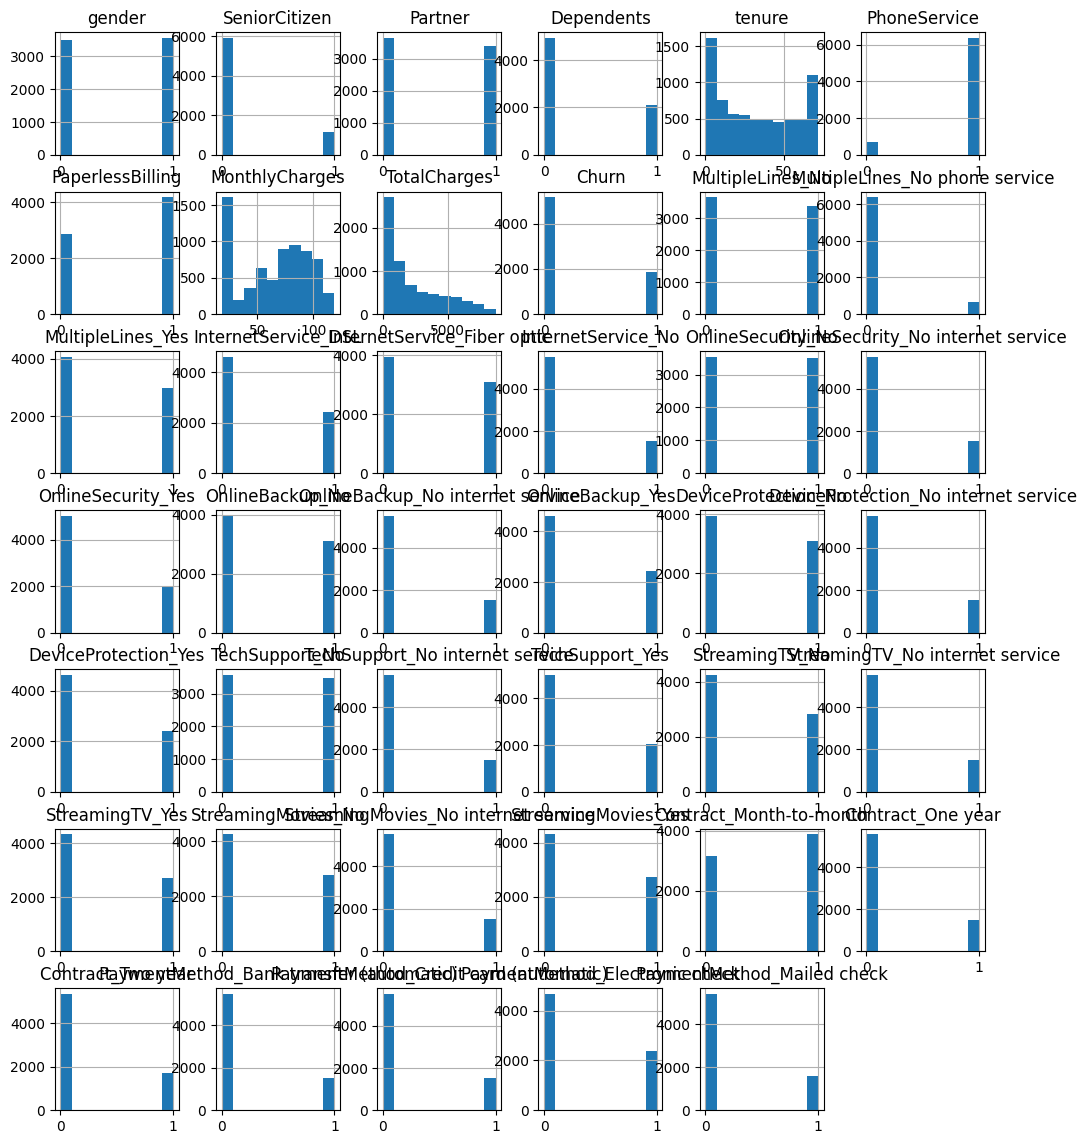

In [7]:
df.hist(figsize=(12,14))
plt.show()

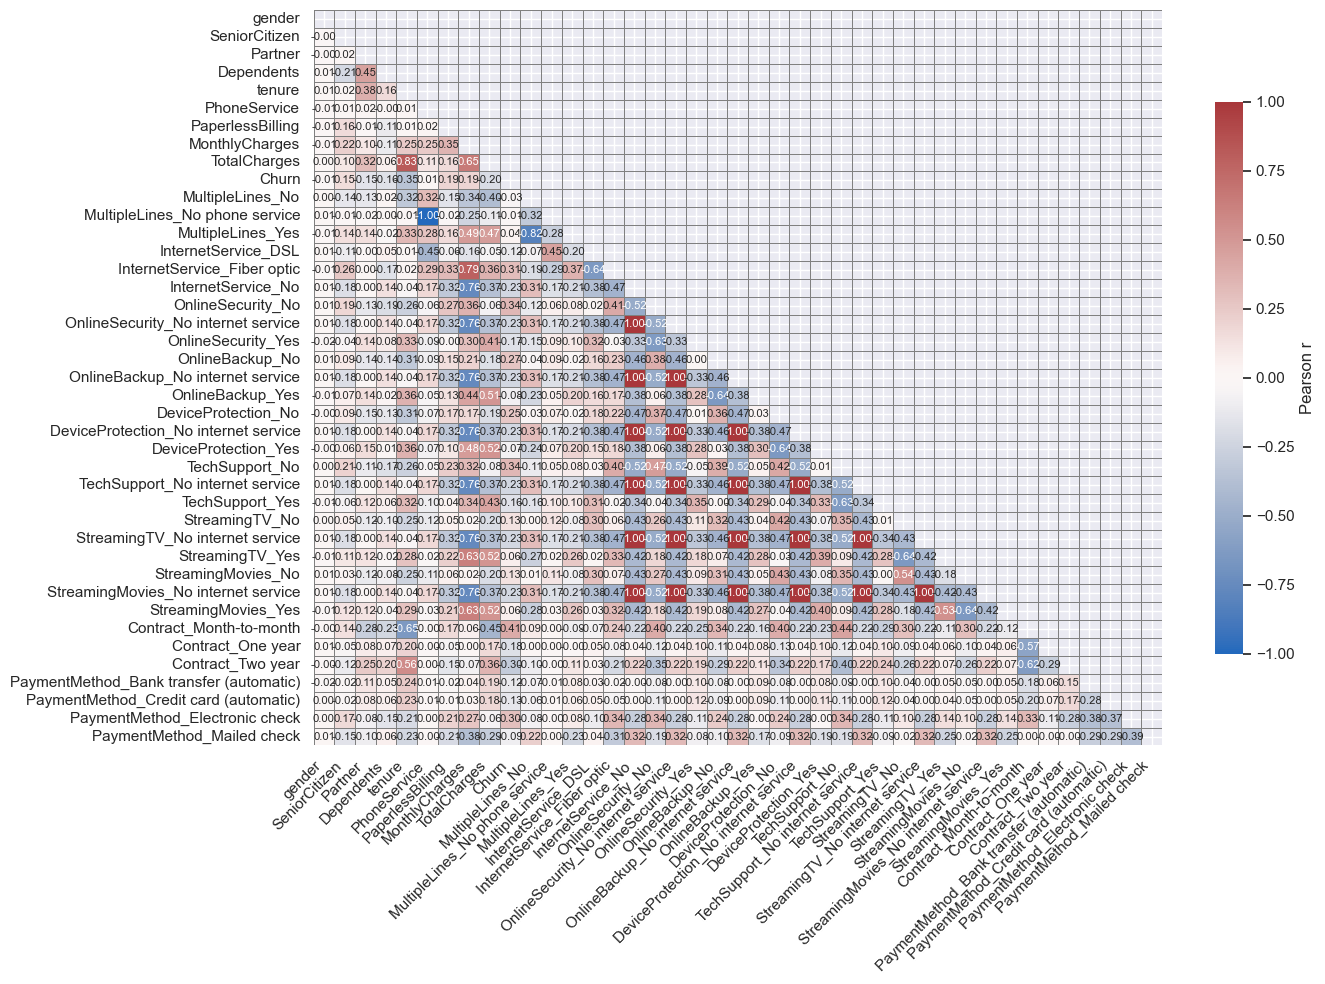

In [8]:
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.set(font_scale=1.0) 

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cmap="vlag",
    center=0,
    linewidths=0.5,
    linecolor="gray",
    square=False,
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
    vmax=1.0,
    vmin=-1.0
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()